## Recommender System with eCommerce dataset
see https://www.linkedin.com/feed/update/urn:li:activity:7382547715160928256/ for discussion.
### Overview
Based on historical data, we build a model which determines ad placement to maximize click-through-rate (CTR). However there are also practical constraints which should be taken to account. For example:<ul>
<li>% of promoted ads, which drives ad revenue</li>
<li>% of ads for a 'hot item', which drives gross sales</li>
</ul>
As these constraints may run counter to the CTR metric, we need to know how much of an impact we expect to see, thus driving a more informed business decision.
</br> 


### Recommender system data features
<ul>
<li><b>item</b>: the content ID being considered (think “a post/video/product”).</li>
<li><b>session</b>: a user’s short browsing window; we rank a slate (e.g., top-10) per session.</li>
<li><b>position</b>: where the item was shown by the logging policy (1 = top). Used for evaluation/bias handling.</li>
<li><b>pop_ctr</b>: item popularity signal = historical click-through rate for that item. Strong baseline, but popularity-biased.</li>
<li><b>fresh</b>: binary flag—item is “new/hot” (we gave those a small boost).</li>
<li><b>editorial</b>: binary flag—item is being promoted (house pick/paid promo).</li>
<li><b>click</b>: 0/1 if the user clicked when the item was shown in that session.</li>
<li><b>propensity</b>: probability the logging policy would put a shown item where it was (accounts for position bias). You saved this at logging time.</li>
</ul>

### Process
#### Load Data
RetailRocket's eCommerce dataset on Kaggle has these sources.
<ul>
<li>events.csv (behavior logs)</li>
<li>item_properties.csv</li>
<li>category_tree.csv</li>
</ul>
From retailrocket_prep.py, we convert the raw files into these parquet files:<ul>
<li>rr_events.parquet - events.csv converted into sessions </li>
<li>rr_slates.parquet - sessionized interaction log from rr_events.parquet</li>
<li>rr_items.parquet - per-item aggregates from item_properties.csv</li>
</ul>

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
from pandas.api.types import is_datetime64_any_dtype

ROOT = Path("assets/recsys-transparent")
DATA = ROOT / "data"
SLATES = DATA / "rr_slates.parquet"
ITEMS  = DATA / "rr_items.parquet"

pd.set_option("display.max_rows", 10)

DATE_SPAN_DAYS = 90 # < 5 months
PCT_ITEMS_PROMOTED = 0.1 # % of items that are editorial content / promoted items
FRESHNESS_DECAY_SPEED_DAYS = 7 # exponential function to measure if an item is 'fresh'
MAX_EDITORIAL_PCT_AT_TOP = 0.3 # max portion of items at 'top of page' to be editorial content
K = 10 # number of items displayed to be considered 'top of page'. 

#### Load full logs (no date filter), sort, compute prev-seen per item

In [2]:
# Load entire dataset by SLATES
s_full = pd.read_parquet(SLATES).copy()

def _coerce_ts(series: pd.Series) -> pd.Series:
    # Already datetime?
    if is_datetime64_any_dtype(series):
        # If tz-naive, localize; if tz-aware, convert
        try:
            if series.dt.tz is None:
                return series.dt.tz_localize("UTC")
            else:
                return series.dt.tz_convert("UTC")
        except Exception:
            pass  # fall through to parsing attempts

    # Try string timestamps
    ts1 = pd.to_datetime(series, utc=True, errors="coerce")

    # If too many NaT, try numeric epochs
    nat_ratio = ts1.isna().mean()
    if nat_ratio > 0.2:
        nums = pd.to_numeric(series, errors="coerce")
        ts2 = pd.to_datetime(nums, unit="s", utc=True, errors="coerce")
        if ts2.notna().mean() > 1 - nat_ratio:
            return ts2
        ts3 = pd.to_datetime(nums, unit="ms", utc=True, errors="coerce")
        if ts3.notna().mean() > 1 - nat_ratio:
            return ts3

    return ts1

print("rows:", len(s_full), "| sessions:", s_full["session"].nunique())
s_full["ts"] = _coerce_ts(s_full["ts"])
print("ts dtype:", s_full["ts"].dtype)
print(f"NaT ratio in ts: {s_full['ts'].isna().mean():.3f}")
if s_full["ts"].isna().any():
    print("Sample unparseable ts values:", s_full.loc[s_full["ts"].isna(), "ts"].head(5).tolist())

# Compute prev-seen on the FULL log (do NOT filter yet)
s_full = s_full.sort_values("ts").reset_index(drop=True)
s_full["last_seen_ts"] = s_full.groupby("item")["ts"].shift(1)
print(f'NaT last_seen_ts ratio: {s_full["last_seen_ts"].isna().mean():.3f}')
display(s_full[["ts","item","last_seen_ts"]].head(5))


rows: 2265417 | sessions: 1755781
ts dtype: datetime64[ns, UTC]
NaT ratio in ts: 0.000
NaT last_seen_ts ratio: 0.102


,ts,item,last_seen_ts
0,2015-05-03 03:00:11.289000+00:00,60987,NaT
1,2015-05-03 03:00:13.048000+00:00,252860,NaT
2,2015-05-03 03:00:24.154000+00:00,33661,NaT
3,2015-05-03 03:00:26.228000+00:00,297662,NaT
4,2015-05-03 03:00:27.031000+00:00,29757,NaT


#### Choose a date window then filter

In [3]:
d1 = s_full["ts"].min().date()
d2 = s_full["ts"].max().date()
print("overall date span:", d1, "→", d2)

# Smoothed (Beta) CTR per item from logs
agg = (s_full.groupby("item")
              .agg(impr=("click","size"), clicks=("click","sum")))
alpha0, beta0 = 2.0, 20.0   # mild prior (~9% baseline)
item_ctr = ((agg["clicks"] + alpha0) / (agg["impr"] + alpha0 + beta0)).astype(float)
ctr_fallback = float(item_ctr.mean())  # for unseen items

# f: limit s_full to specific range
cut = s_full["ts"].max().normalize() - pd.Timedelta(days=DATE_SPAN_DAYS)
mask = s_full["ts"] >= cut
f = s_full.loc[mask].copy()

d1 = f["ts"].min().date()
d2 = f["ts"].max().date()
print("actual date span:", d1, "→", d2)

print("window rows:", len(f), "| sessions:", f["session"].nunique())
f[["ts","item","last_seen_ts"]].head(10)


overall date span: 2015-05-03 → 2015-09-18
actual date span: 2015-06-20 → 2015-09-18
window rows: 1464801 | sessions: 1146084


,ts,item,last_seen_ts
800616,2015-06-20 00:00:01.197000+00:00,458643,2015-06-19 12:41:11.675000+00:00
800617,2015-06-20 00:00:01.995000+00:00,292007,2015-06-19 23:05:08.322000+00:00
800618,2015-06-20 00:00:06.982000+00:00,445424,2015-05-29 20:41:05.616000+00:00
800619,2015-06-20 00:00:10.735000+00:00,76196,2015-06-19 20:25:03.876000+00:00
800620,2015-06-20 00:00:14.084000+00:00,233938,2015-06-18 18:49:45.618000+00:00
800621,2015-06-20 00:00:16.599000+00:00,65723,2015-06-18 22:36:02.435000+00:00
800622,2015-06-20 00:00:20.305000+00:00,133818,2015-06-18 22:20:50.564000+00:00
800623,2015-06-20 00:00:20.927000+00:00,361420,2015-06-03 22:39:39.396000+00:00
800624,2015-06-20 00:00:27.304000+00:00,51984,2015-06-17 15:33:25.002000+00:00
800625,2015-06-20 00:00:33.781000+00:00,49918,2015-06-17 17:49:16.472000+00:00


Randomly select items for 'editorial content' (promoted) per PCT_ITEMS_REPORTED

In [4]:
from pandas.api.types import is_integer_dtype

it = pd.read_parquet(ITEMS).copy() if ITEMS.exists() else pd.DataFrame(columns=["item"])
    # category in items.parquet is numeric.
if not is_integer_dtype(it["category"]):
    it["category"] = pd.to_numeric(it["category"], errors="coerce")
it["category"] = pd.Series(it["category"], dtype="Int64").fillna(-1).astype("Int64")


if "editorial_item" not in it.columns:
    # synthesize 10% editorial per unique item in the window (stable)
    uniq_items = f["item"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(42)
    mark = pd.Series(0, index=uniq_items, dtype="int8")
    mark.iloc[rng.choice(len(mark), size=max(1, int(PCT_ITEMS_PROMOTED*len(mark))), replace=False)] = 1
    it = pd.DataFrame({"item": mark.index, "editorial_item": mark.values})

f = f.merge(it[["item","editorial_item","category"]], on="item", how="left")
f["editorial"] = f["editorial_item"].fillna(0).astype("int8")

print(f'editorial share: {f["editorial"].mean():.3}')
f[["item","editorial"]].head(3)


editorial share: 0.0906


,item,editorial
0,458643,0
1,292007,0
2,445424,0


Estimate editorial coverage -- % sessions w/ at least 1 editorial item

In [5]:
def editorial_coverage(F):
    g = F.groupby("session")["editorial"].sum()
    has_any = (g > 0).mean()
    return float(has_any)

print(f"sessions with ≥1 editorial item in slate: {editorial_coverage(f):.3f}")


sessions with ≥1 editorial item in slate: 0.111


Determine Freshness: time since previous impression of that item (per row)

In [6]:
# compute per-row age in days since previous impression
age_days = (f["ts"] - f["last_seen_ts"]).dt.total_seconds() / 86400.0
# First occurrence is NaN → treat as "very old"
age_days = age_days.fillna(999).clip(lower=0)

f["fresh_score"] = np.exp(-age_days / FRESHNESS_DECAY_SPEED_DAYS).astype("float32")

print("age_days stats:", np.nanpercentile(age_days, [0,50,90,99]))
print("fresh_score mean:", float(f["fresh_score"].mean()))
f[["ts","last_seen_ts","fresh_score"]].head(5)


age_days stats: [  0.           1.75938855  39.87320082 999.        ]
fresh_score mean: 0.6262425184249878


,ts,last_seen_ts,fresh_score
0,2015-06-20 00:00:01.197000+00:00,2015-06-19 12:41:11.675000+00:00,0.934874
1,2015-06-20 00:00:01.995000+00:00,2015-06-19 23:05:08.322000+00:00,0.994569
2,2015-06-20 00:00:06.982000+00:00,2015-05-29 20:41:05.616000+00:00,0.048814
3,2015-06-20 00:00:10.735000+00:00,2015-06-19 20:25:03.876000+00:00,0.978885
4,2015-06-20 00:00:14.084000+00:00,2015-06-18 18:49:45.618000+00:00,0.840584


#### Determine a smoothed form of click-thru-rate. This helps in cases where number of impressions is small.
If impressions is small, pop_ctr_smooth is the global CTR. If it is large, it becomes the local CTR for that item.

In [7]:
# from the full slates (s_full)
agg = (s_full
       .groupby("item")
       .agg(impr=("click","size"), clicks=("click","sum"))
       .reset_index())

# Fit a global Beta prior (quick method-of-moments)
p_hat = agg["clicks"].sum() / agg["impr"].sum()

alpha0 = max(1.0, p_hat * 100.0)
beta0  = max(1.0, (1.0 - p_hat) * 100.0)

# Smoothed rate
agg["pop_ctr_smooth"] = (agg["clicks"] + alpha0) / (agg["impr"] + alpha0 + beta0)

# Merge into your window frame
f = f.merge(agg[["item","impr","clicks","pop_ctr_smooth"]], on="item", how="left")
f["pop_ctr_smooth"] = f["pop_ctr_smooth"].fillna(p_hat).astype("float32")



f[["item","pop_ctr_smooth"]].head(3)

,item,pop_ctr_smooth
0,458643,0.015944
1,292007,0.010855
2,445424,0.018723


#### Build tiny session cache (arrays only); K clipping baked in

In [8]:
# Item-level features we'll need for extras
item_feats = (f[["item","fresh_score","editorial"]]
                .drop_duplicates("item")
                .merge(f[["item","pop_ctr_smooth"]].drop_duplicates("item"), on="item", how="left"))

# Prefer item->category from items file if you have it; else infer from window
if "category" in f.columns:
    it_cat = f[["item","category"]].drop_duplicates("item")
else:
    it_cat = pd.DataFrame({"item": f["item"].unique(), "category": None})

item_feats = item_feats.merge(it_cat, on="item", how="left")

# Build category -> item pool (fallback to global)
cats_series = pd.Series(item_feats["category"], dtype="Int64").fillna(-1).astype("Int64")

pool_by_cat = {
    int(c): g["item"].to_numpy()
    for c, g in item_feats.assign(category=cats_series).groupby("category")
}
global_pool = item_feats["item"].to_numpy()

# fast maps
ed_map    = item_feats.set_index("item")["editorial"].astype("int8")
fresh_map = item_feats.set_index("item")["fresh_score"].astype(float)
base_map  = item_feats.set_index("item")["pop_ctr_smooth"].astype(float)
cat_map   = item_feats.set_index("item")["category"].astype("Int64")

# ---------- AUGMENTED SESSION CACHE ----------
def build_session_cache_augmented(F, k=10, max_sessions=300, extras_per_session=30, seed=7):
    rng = np.random.default_rng(seed)
    sess = F["session"].drop_duplicates().to_numpy()
    if len(sess) > max_sessions:
        sess = rng.choice(sess, size=max_sessions, replace=False)
    cache = []
    for sid in sess:
        g = F.loc[F["session"] == sid,
                  ["item","category","editorial","fresh_score","pop_ctr_smooth","click","ts"]]
        if g.empty:
            continue

        logged_items = set(g["item"].tolist())

        # categories present in this session (as ints). If none, use [-1]
        cats = g["category"].dropna().astype("Int64").unique().tolist()
        cats = [int(c) for c in cats if pd.notna(c)]
        if not cats:
            cats = [-1]

        extra_items = []
        for c in cats:
            pool = pool_by_cat.get(c, global_pool)
            choices = np.array([x for x in pool if x not in logged_items])
            if choices.size == 0:
                continue
            take = min(extras_per_session // max(1, len(cats)), choices.size)
            if take > 0:
                extra_items.extend(rng.choice(choices, size=take, replace=False).tolist())

        if not extra_items:
            choices = np.array([x for x in global_pool if x not in logged_items])
            if choices.size > 0:
                extra_items = rng.choice(choices, size=min(extras_per_session, choices.size),
                                         replace=False).tolist()

        # assemble extras frame (click=0)
        if extra_items:
            # ts_ref = max event time in this session (for freshness alignment)
            ts_ref = g["ts"].max()
            extras = pd.DataFrame({"item": extra_items})
            extras["category"]  = extras["item"].map(cat_map).fillna(-1)
            extras["editorial"] = extras["item"].map(ed_map).fillna(0).astype(np.int8)
            extras["fresh_score"] = extras["item"].map(fresh_map).fillna(0.0).astype(float)
            extras["pop_ctr_smooth"] = extras["item"].map(base_map).fillna(base_map.mean()).astype(float)
            extras["click"] = 0
            extras["ts"] = ts_ref
            g_aug = pd.concat([g[["item","editorial","fresh_score","pop_ctr_smooth","click","ts"]],
                               extras[["item","editorial","fresh_score","pop_ctr_smooth","click","ts"]]],
                              ignore_index=True)
        else:
            g_aug = g[["item","editorial","fresh_score","pop_ctr_smooth","click","ts"]]

        # base = smoothed popularity; rank-normalize to balance
        base = g_aug["pop_ctr_smooth"].to_numpy(float)
        ranks = pd.Series(base).rank(method="average").to_numpy()
        base_r = (ranks - ranks.mean()) / (ranks.std() + 1e-6)

        cache.append({
            "item":      g_aug["item"].to_numpy(np.int64),
            "editorial": g_aug["editorial"].to_numpy(np.int8),
            "fresh":     g_aug["fresh_score"].to_numpy(np.float32),
            "click":     g_aug["click"].to_numpy(np.int8),
            "base":      base_r.astype(np.float32),
        })
    return cache



#### Compute metrics & smoke test different promo weights
Verify values for NDCG, editorial %, and freshness do not break down over the range of the promo parameter.

In [9]:
def fast_metrics(session_cache, w_promo: float, w_fresh: float, k: int = K):
    nds, ed_share, fr_share = [], [], []
    for c in session_cache:
        # standardize freshness per session
        fs = c["fresh"]; fs = (fs - fs.mean()) / (fs.std() + 1e-6)
        final = c["base"] + w_promo*c["editorial"] + w_fresh*fs
        n = final.size
        if n == 0: 
            continue
        kk = min(k, n)
        idx = np.argpartition(final, -kk)[-kk:]
        idx = idx[np.argsort(final[idx])[::-1]]
        ed_share.append(c["editorial"][idx].mean())
        fr_share.append(c["fresh"][idx].mean())
        gains = c["click"][idx].astype(float)
        if gains.size:
            disc  = 1.0/np.log2(np.arange(2, gains.size+2))
            dcg   = float((gains*disc).sum())
            ideal = float((np.sort(gains)[::-1]*disc).sum()) or 1.0
            nds.append(dcg/ideal)
    return {
        "ndcg": float(np.mean(nds)) if nds else 0.0,
        "exp_editorial": float(np.mean(ed_share)) if ed_share else 0.0,
        "exp_fresh": float(np.mean(fr_share)) if fr_share else 0.0,
        "sessions": len(session_cache),
    }


def fast_metrics_capped(cache, w_promo, w_fresh, k=10, editorial_cap=MAX_EDITORIAL_PCT_AT_TOP):
    # compute final scores
    nds, ed_share, fr_share = [], [], []
    for c in cache:
        final = c["base"] + w_promo*c["editorial"] + w_fresh*c["fresh"]
        n = final.size
        if n == 0: continue
        kk = min(k, n)

        # rank as usual
        idx = np.argpartition(final, -kk)[-kk:]
        idx = idx[np.argsort(final[idx])[::-1]]

        # enforce cap by demoting editorial items if needed
        ed_mask = c["editorial"][idx].astype(bool)
        max_ed = int(np.floor(editorial_cap * kk))
        if ed_mask.sum() > max_ed:
            # keep top (kk) but swap out excess editorial with next best non-editorial
            non_ed = np.where(~c["editorial"].astype(bool))[0]
            alt = non_ed[np.argsort(final[non_ed])[::-1]]
            keep_ed = np.where(ed_mask)[0][:max_ed]
            keep_non = np.where(~ed_mask)[0]
            needed = kk - (len(keep_ed) + len(keep_non))
            if needed > 0:
                keep_non = np.concatenate([keep_non, alt[:needed]])
            idx = idx[np.concatenate([keep_ed, keep_non])[:kk]]

        # metrics
        ed_share.append(c["editorial"][idx].mean())
        fr_share.append(c["fresh"][idx].mean())
        gains = c["click"][idx].astype(float)
        if gains.size:
            disc = 1.0/np.log2(np.arange(2, gains.size+2))
            dcg  = float((gains*disc).sum())
            ideal= float((np.sort(gains)[::-1]*disc).sum()) or 1.0
            nds.append(dcg/ideal)
    return {
        "ndcg": float(np.mean(nds)) if nds else 0.0,
        "exp_editorial": float(np.mean(ed_share)) if ed_share else 0.0,
        "exp_fresh": float(np.mean(fr_share)) if fr_share else 0.0,
    }


In [10]:
session_cache = build_session_cache_augmented(f, max_sessions=300, extras_per_session=40)
def editorial_coverage_from_cache(cache):
    return np.mean([c["editorial"].sum() > 0 for c in cache])
print("coverage after augmentation:", editorial_coverage_from_cache(session_cache))
for w in (0.0, 0.5, 1.0, 2.0, 3.0):
    print(f"promo={w:.1f}", fast_metrics(session_cache, w_promo=w, w_fresh=0.5, k=10))


coverage after augmentation: 0.88
promo=0.0 {'ndcg': 0.016399069297160625, 'exp_editorial': 0.09466666666666666, 'exp_fresh': 0.20575976371765137, 'sessions': 300}
promo=0.5 {'ndcg': 0.016399069297160625, 'exp_editorial': 0.13366666666666666, 'exp_fresh': 0.2061930149793625, 'sessions': 300}
promo=1.0 {'ndcg': 0.016257384384460165, 'exp_editorial': 0.19933333333333333, 'exp_fresh': 0.2127848118543625, 'sessions': 300}
promo=2.0 {'ndcg': 0.014937582197020708, 'exp_editorial': 0.31666666666666665, 'exp_fresh': 0.2218402624130249, 'sessions': 300}
promo=3.0 {'ndcg': 0.011345817515618625, 'exp_editorial': 0.3773333333333333, 'exp_fresh': 0.22051376104354858, 'sessions': 300}


In [11]:
print(f["editorial"].mean(), f["fresh_score"].mean())
print(np.percentile(f["pop_ctr_smooth"], [0,50,90,99]))


0.09059933738439556 0.6262425
[0.00095055 0.01907305 0.03544576 0.07037062]


### Show results as function of Promotion and Freshness parameters
Editorial share: % of Top-K items shown that are promoted, averaged across sessions.</br>
Expected CTR: a proxy for expected click-thru-rate</br>
NDCG: Normalized Discounted Cumulative Gain

In [52]:
from ipywidgets import interact, FloatSlider, widgets
from functools import lru_cache
from matplotlib import pyplot as plt
import ipywidgets as W
from ipywidgets import Layout, HBox, VBox, Label
from IPython.display import display
COLUMN_SPACING_PX = 32

# ---- 1) Widgets (distinct names) ----
promo_sl = W.FloatSlider(
    value=0.0, min=0.0, max=3.0, step=0.1,
    description="Promotion", continuous_update=False, readout_format=".1f",
    layout=Layout(width="350px")
)
fresh_sl = W.FloatSlider(
    value=0.5, min=0.0, max=2.0, step=0.1,
    description="Freshness", continuous_update=False, readout_format=".1f",
    layout=Layout(width="350px")
)

use_cap_chk = W.Checkbox(value=False, description="Use editorial cap")
use_cap_chk.indent = False

cap_frac_sl = W.FloatSlider(
    value=0.20, min=0.0, max=0.6, step=0.05,
    description="Cap fraction", continuous_update=False, readout_format=".2f",
    layout=Layout(width="300px")
)

def _toggle_cap(change):
    cap_frac_sl.disabled = not change["new"]
use_cap_chk.observe(_toggle_cap, names="value")
_toggle_cap({"new": use_cap_chk.value})

# --- Controls layout (forces full-width row + spacer) ---
for s in (promo_sl, fresh_sl, cap_frac_sl):
    s.layout = W.Layout(width="360px")  # sliders fixed width inside the columns

left_col  = VBox([Label("Ranking knobs"), promo_sl, fresh_sl],
                 layout=W.Layout(flex="0 0 380px"))  # fixed
right_col = VBox([Label("Editorial controls"), use_cap_chk, cap_frac_sl],
                 layout=W.Layout(flex="0 0 360px", align_self="flex-start"))  # fixed

spacer = W.Box(layout=W.Layout(flex="1 1 0"))  # <— grows to fill all remaining space

control_bar = HBox(
    [left_col, spacer, right_col],
    layout=W.Layout(
        width="70%",   # 100% makes bar take entire row         
        align_items="flex-start",
        gap="32px",
    ),
)

# enable/disable cap slider based on checkbox
def _toggle_cap(change):
    cap_frac_sl.disabled = not change["new"]
use_cap_chk.observe(_toggle_cap, names="value")
_toggle_cap({"new": use_cap_chk.value})  # initialize



S = s_full.copy()

# --- 1) Selectors ------------------------------------------------------------
def select_topk_open(c, w_promo: float, w_fresh: float, k: int):
    fr = c["fresh"]
    fr_std = (fr - fr.mean()) / (fr.std() + 1e-6)
    final = c["base"] + w_promo*c["editorial"] + w_fresh*fr_std
    n = final.size
    kk = min(k, n)
    idx = np.argpartition(final, -kk)[-kk:]
    return idx[np.argsort(final[idx])[::-1]]  # sorted Top-K

def select_topk_capped(c, w_promo: float, w_fresh: float, k: int, cap_frac: float = 0.2):
    """Hard cap: at most floor(k*cap_frac) editorial items in Top-K."""
    fr = c["fresh"]
    fr_std = (fr - fr.mean()) / (fr.std() + 1e-6)
    base  = c["base"]
    promo = c["editorial"].astype(float)

    # score before cap
    score = base + w_promo*promo + w_fresh*fr_std

    # start with the open ranking
    order = np.argsort(score)[::-1]
    kk = min(k, score.size)

    cap = int(np.floor(kk * cap_frac))
    taken, promo_used = [], 0
    for i in order:
        if len(taken) >= kk:
            break
        if promo[i] >= 0.5:  # editorial flag
            if promo_used < cap:
                taken.append(i); promo_used += 1
            else:
                continue
        else:
            taken.append(i)
    return np.array(taken[:kk], dtype=int)

# --- 2) Core metric calculator (shared) --------------------------------------
def compute_metrics_with_selector(cache, selector_fn, w_promo: float, w_fresh: float, k: int = 10):
    nds, ed_share, fr_share, exp_ctrs = [], [], [], []

    for c in cache:
        if c["base"].size == 0: 
            continue
        idx = selector_fn(c, w_promo, w_fresh, k)
        kk  = idx.size

        # NDCG
        gains = c["click"][idx].astype(float)
        disc  = 1.0 / np.log2(np.arange(2, kk+2))
        dcg   = float((gains * disc).sum())
        ideal = float((np.sort(gains)[::-1] * disc).sum()) or 1.0
        nds.append(dcg / ideal)

        # Exposure
        ed_share.append(c["editorial"][idx].mean())
        fr_share.append(c["fresh"][idx].mean())

        # Expected CTR proxy (align prob → Top-K order, weight by exam curve)
        p_click_full = item_ctr.reindex(c["item"]).fillna(ctr_fallback).to_numpy()
        exp_ctrs.append(float((EXAM[:kk] * np.clip(p_click_full[idx], 0.0, 1.0)).sum()))

    return {
        "ndcg":         float(np.mean(nds)) if nds else 0.0,
        "exp_editorial":float(np.mean(ed_share)) if ed_share else 0.0,
        "exp_fresh":    float(np.mean(fr_share)) if fr_share else 0.0,
        "exp_ctr":      float(np.mean(exp_ctrs)) if exp_ctrs else 0.0,
        "sessions":     len(cache),
    }

# --- 3) Cached wrapper (key includes mode/cap) --------------------------------
from functools import lru_cache

@lru_cache(maxsize=2048)
def metrics_cached(mode: str, w_promo: float, w_fresh: float, cap: float, k: int):
    sel = (lambda c, wp, wf, kk: select_topk_open(c, wp, wf, kk)) if mode == "open" \
          else (lambda c, wp, wf, kk: select_topk_capped(c, wp, wf, kk, cap))
    return compute_metrics_with_selector(session_cache, sel, w_promo, w_fresh, k)

# --- 4) Sweep + render with a switch -----------------------------------------
def sweep(mode: str, w_fresh: float, cap: float, promo_grid=np.linspace(0, 3, 31), k: int = 10):
    rows = []
    for p in promo_grid:
        m = metrics_cached(mode, round(p,3), round(w_fresh,3), round(cap,3), k)
        rows.append({"promo": p, **m})
    return pd.DataFrame(rows)

def render(promo: float, fresh: float, use_cap: bool = False, cap_frac: float = 0.2):
    mode = "capped" if use_cap else "open"
    cur  = metrics_cached(mode, round(promo,3), round(fresh,3), round(cap_frac,3), K)
    df   = sweep(mode, fresh, cap_frac, k=K)

    print(f"[{mode}] cap={np.round(cap_frac,2) if use_cap else '—'} | Editorial {cur['exp_editorial']*100:4.1f}%"
          f"  Fresh {cur['exp_fresh']*100:4.1f}%  NDCG@{K} {cur['ndcg']:.4f}  ExpCTR {cur['exp_ctr']:.3f}"
          f"  Sessions {cur['sessions']}")

    plt.figure(figsize=(14,3.6))
    for i,(y,label) in enumerate([
        (df["exp_editorial"]*100, "Editorial share (%)"),
        (df["exp_ctr"], "Expected CTR (proxy)"),
        (df["ndcg"],   f"NDCG@{K} (macro)"),
    ], start=1):
        plt.subplot(1,3,i)
        plt.plot(df["promo"], y, marker=".")
        # current-point marker
        x = promo
        y_cur = {"Editorial share (%)": cur["exp_editorial"]*100,
                 "Expected CTR (proxy)": cur["exp_ctr"],
                 f"NDCG@{K} (macro)"   : cur["ndcg"]}[label]
        plt.scatter([x],[y_cur], s=80)
        plt.axvline(x, linestyle="--", alpha=0.3)
        plt.xlabel("Promotion weight"); plt.ylabel(label); plt.grid(True, alpha=0.25)
    plt.tight_layout(); plt.show()

out = W.interactive_output(
    render,  # do not define render in this same cell; it should already exist
    {"promo": promo_sl,
    "fresh": fresh_sl,
    "use_cap": use_cap_chk,
    "cap_frac": cap_frac_sl}
)

display(control_bar, out)




Output()

# Archive (in work)

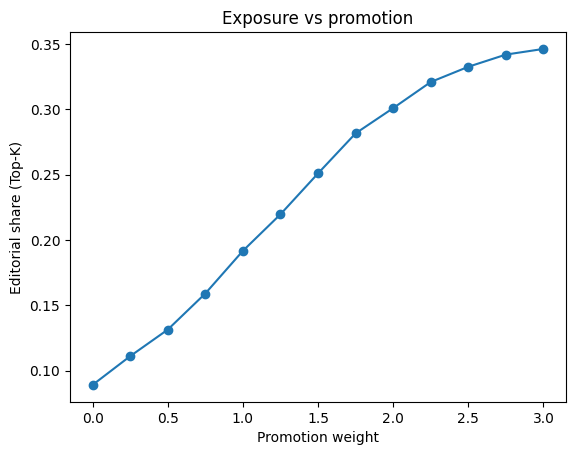

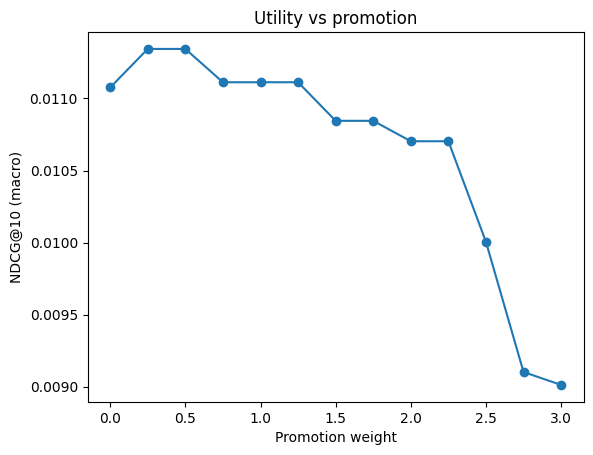

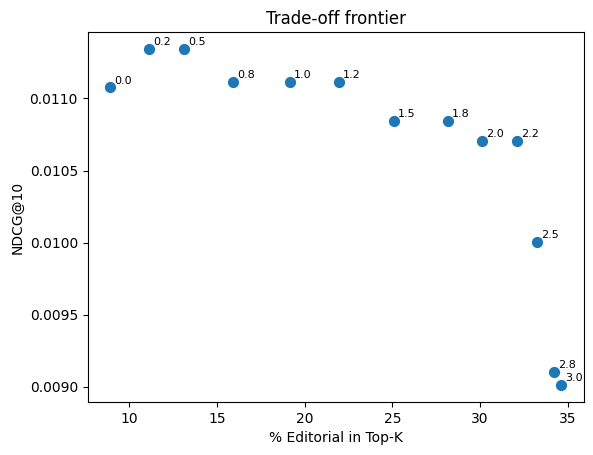

In [48]:
import numpy as np, matplotlib.pyplot as plt

def sweep(session_cache, w_fresh=0.5, promo_grid=None):
    if promo_grid is None:
        promo_grid = np.linspace(0, 3,31)
    out = []
    for p in promo_grid:
        m = fast_metrics(session_cache, w_promo=p, w_fresh=w_fresh, k=K)
        out.append({"promo": p, **m})
    return pd.DataFrame(out)

grid = np.linspace(0, 3, 31)
df = sweep(session_cache, w_fresh=0.5, promo_grid=grid)

fig, ax = plt.subplots()
ax.plot(df["promo"], df["exp_editorial"], marker="o")
ax.set_xlabel("Promotion weight")
ax.set_ylabel("Editorial share (Top-K)")
ax.set_title("Exposure vs promotion")
plt.show()

fig, ax = plt.subplots()
ax.plot(df["promo"], df["ndcg"], marker="o")
ax.set_xlabel("Promotion weight")
ax.set_ylabel("NDCG@10 (macro)")
ax.set_title("Utility vs promotion")
plt.show()

fig, ax = plt.subplots()
ax.scatter(df["exp_editorial"]*100, df["ndcg"], s=50)
for _, r in df.iterrows():
    ax.annotate(f'{r["promo"]:.1f}', (r["exp_editorial"]*100, r["ndcg"]), fontsize=8, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("% Editorial in Top-K")
ax.set_ylabel("NDCG@10")
ax.set_title("Trade-off frontier")
plt.show()


### Metrics
Inverse Probability Scoring (IPS): un-normalized weighted mean</br>
Self-normalized IPS (SNIPS): normalized rate.</br>
Propensity: Probability of placing an ad at a particular place given the context.</br>

In [49]:
# Create hour and day-of-week features from timestamp
f["hour"] = f["ts"].dt.hour.astype("int16")            # 0..23
f["dow"]  = f["ts"].dt.dayofweek.astype("int8")        # 0=Mon .. 6=Sun

# Create 'category' feature from rr_items
it = pd.read_parquet(ITEMS)
s_full = s_full.merge(it[["item","category"]].drop_duplicates("item"),
        on="item", how="left"
    )


# 1) Target-encode on FULL history (less noisy)
cat_ctr = s_full.groupby("category")["click"].mean().rename("cat_ctr").astype(float)

# 2) Attach to your window frame f
f = f.merge(cat_ctr, on="category", how="left")
f["cat_ctr"] = f["cat_ctr"].fillna(f["click"].mean())

FEATS = ["cat_ctr", "category", "fresh_score","editorial","dow", "hour","pop_ctr_smooth"]
# 1a) For each session, keep all logged candidates; ensure negatives exist
def _sample_train_rows(F: pd.DataFrame, negatives_per_click=5, features=FEATS, seed=7):
    rng = np.random.default_rng(seed)
    out = []
    for sid, g in F.groupby("session"):
        g = g[["session","item","click"]+features].copy()
        pos = g[g["click"]==1]
        neg = g[g["click"]==0]
        if len(pos)==0:
            # keep a small random subset of non-clicks to give contrast
            neg = neg.sample(n=min(10, len(neg)), random_state=int(rng.integers(1e9))) if len(neg)>10 else neg
            g = pd.concat([pos, neg], ignore_index=True)
        else:
            take = min(len(neg), negatives_per_click*len(pos))
            neg = neg.sample(n=take, random_state=int(rng.integers(1e9))) if take>0 else neg.head(0)
            g = pd.concat([pos, neg], ignore_index=True)
        out.append(g)
    return pd.concat(out, ignore_index=True)

train = _sample_train_rows(f, negatives_per_click=5)


# 1b) Features/label/groups (group = session lengths)

X = train[FEATS].astype(float).copy()
y = train["click"].astype(int).to_numpy()
group = train.groupby("session").size().to_numpy()
print(X.shape, y.mean(), len(group), "groups")


(952565, 7) 0.020312524604620158 750498 groups


In [50]:
import lightgbm as lgb

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=13
)
ranker.fit(X, y, group=group)
print("train ndcg@:", ranker.best_score_ if hasattr(ranker, "best_score_") else "ok")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 952565, number of used features: 7
train ndcg@: defaultdict(<class 'collections.OrderedDict'>, {})


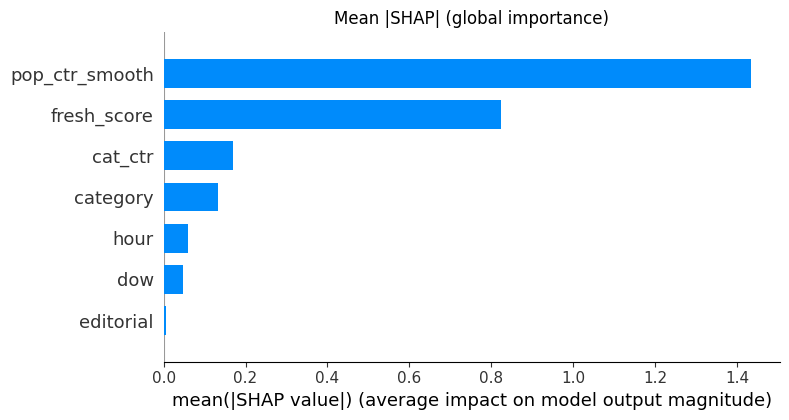

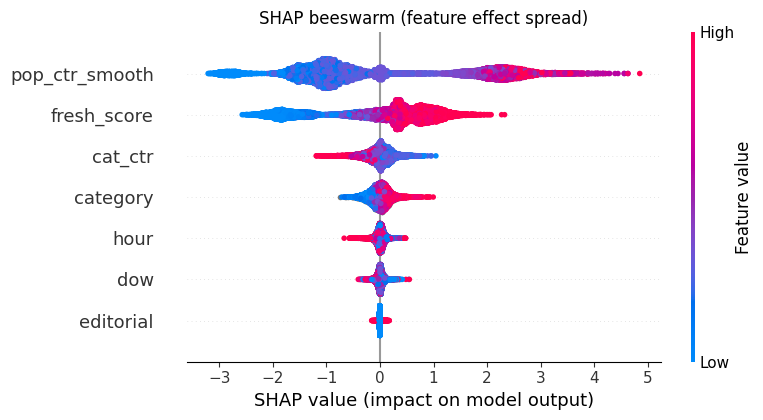

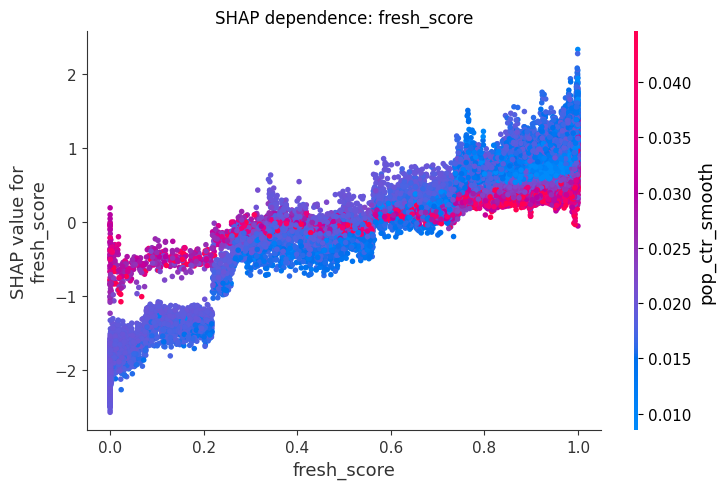

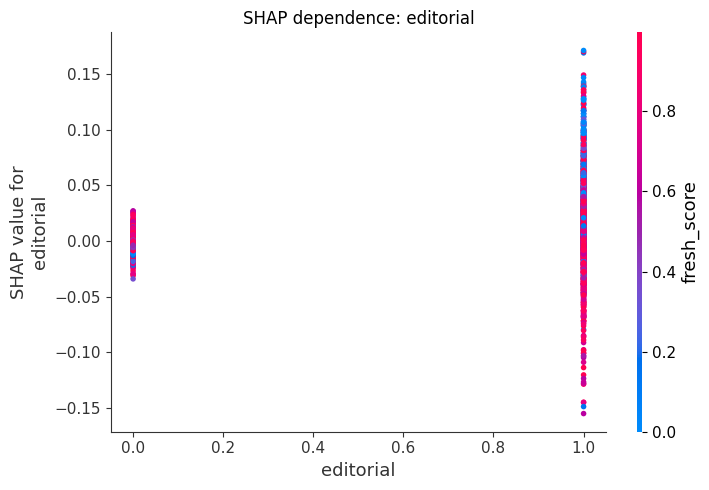

In [51]:
import shap, matplotlib.pyplot as plt
expl = shap.TreeExplainer(ranker.booster_)  # works for LGBM
# sample to keep plots fast
SAMP = X.sample(n=min(20000, len(X)), random_state=0)
sh = expl.shap_values(SAMP)
base = expl.expected_value

# 3a) Global importance (bar)
shap.summary_plot(sh, SAMP, plot_type="bar", show=False)
plt.title("Mean |SHAP| (global importance)")
plt.tight_layout(); plt.show()

# 3b) Beeswarm (distribution)
shap.summary_plot(sh, SAMP, show=False)
plt.title("SHAP beeswarm (feature effect spread)")
plt.tight_layout(); plt.show()

# 3c) Dependence: fresh_score and editorial
for feat in ["fresh_score","editorial"]:
    shap.dependence_plot(feat, sh, SAMP, show=False)
    plt.title(f"SHAP dependence: {feat}")
    plt.tight_layout(); plt.show()


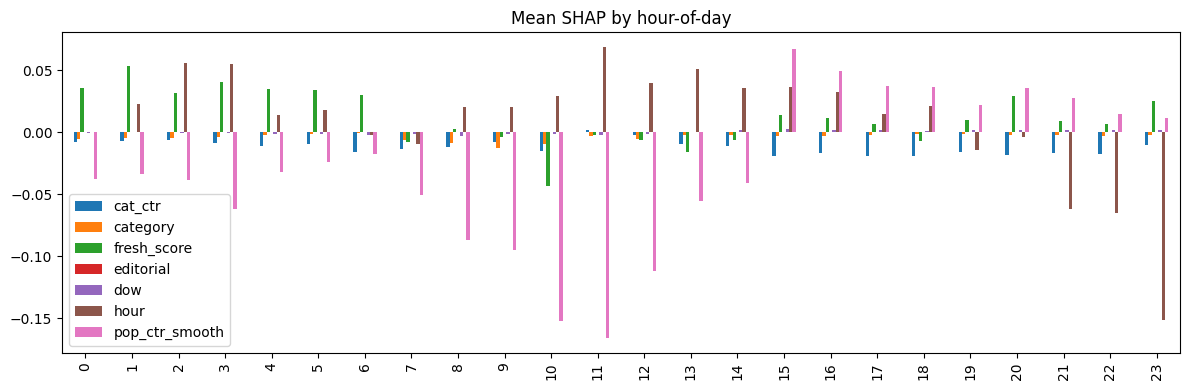

In [52]:
def cohort_shap_mean(frame, model, by="hour"):
    ex = shap.TreeExplainer(model.booster_)
    rows = []
    for k, g in frame.groupby(by):
        gg = g[FEATS].astype(float)
        shv = ex.shap_values(gg)
        rows.append(pd.Series(shv.mean(0), index=FEATS, name=k))
    return pd.DataFrame(rows).sort_index()

co = cohort_shap_mean(train, ranker, by="hour")
co.plot(kind="bar", figsize=(12,4))
plt.title("Mean SHAP by hour-of-day"); plt.tight_layout(); plt.show()


#### One-hot top-K categories

In [53]:
# 1) Pick top-K categories in window f
topK = f["category"].value_counts().head(20).index.tolist()

# 2) One-hot them
for c in topK:
    mask = f["category"].eq(c)  # boolean with possible NA
    f[f"cat_{c}"] = mask.fillna(False).astype("int8")

# 3) Rebuild training and features
cat_feats = [f"cat_{c}" for c in topK]
FEATS = ["pop_ctr_smooth","fresh_score","editorial","hour","dow"] + cat_feats
train = _sample_train_rows(f, negatives_per_click=5, features=FEATS)
X = train[FEATS].astype(float)
y = train["click"].astype(int).to_numpy()
group = train.groupby("session").size().to_numpy()

# 4) Retrain + SHAP
ranker.fit(X, y, group=group)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 952565, number of used features: 25


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


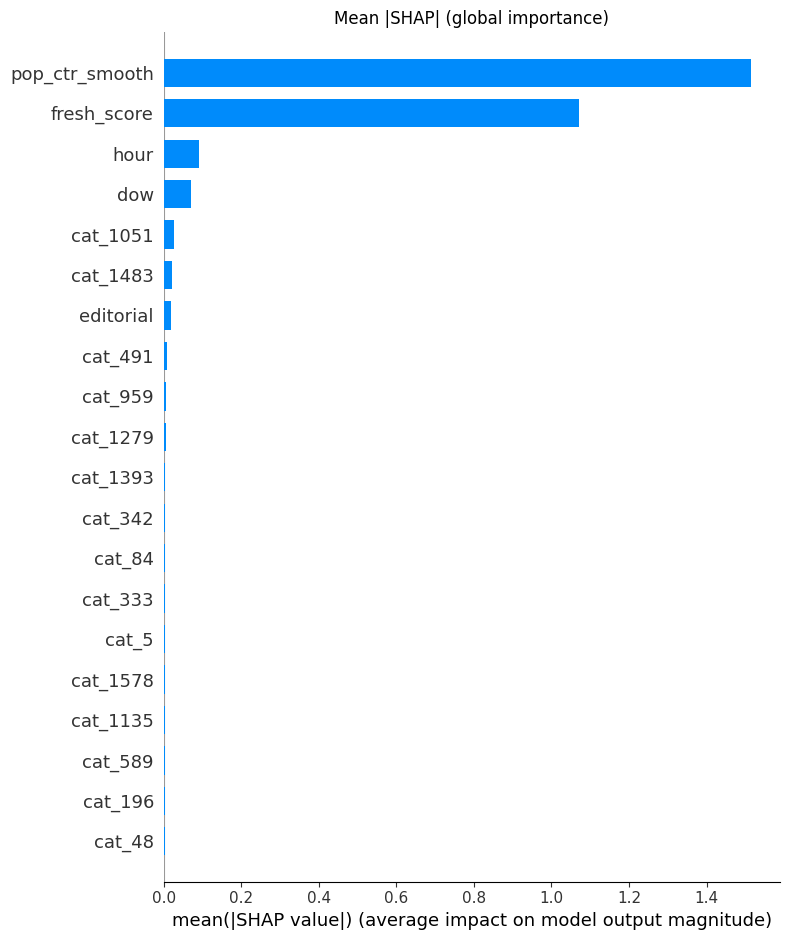

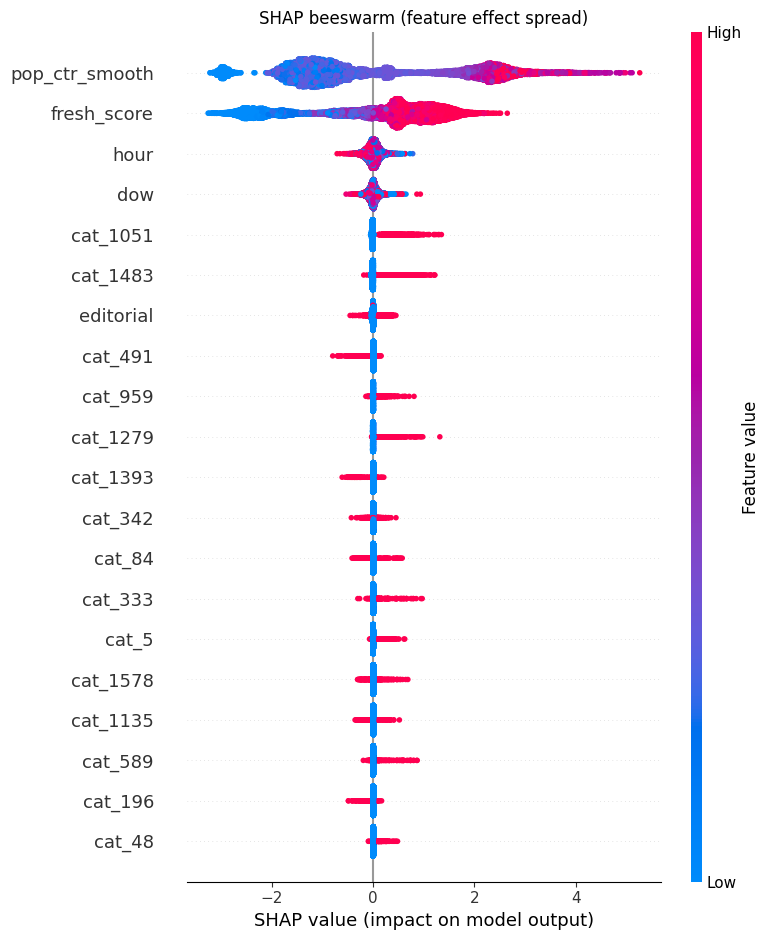

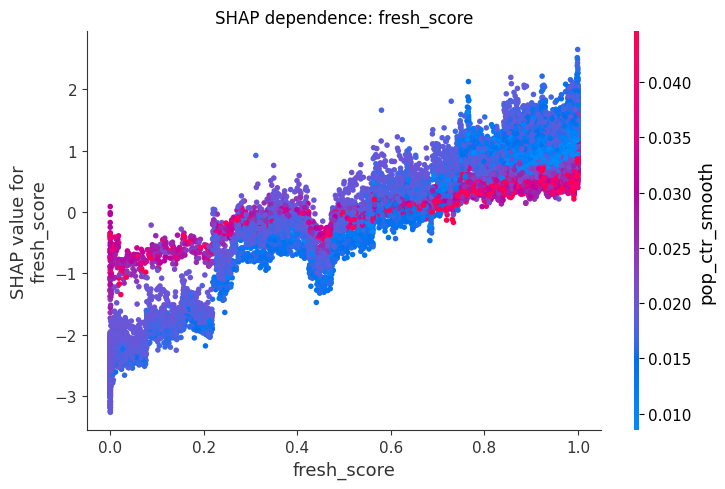

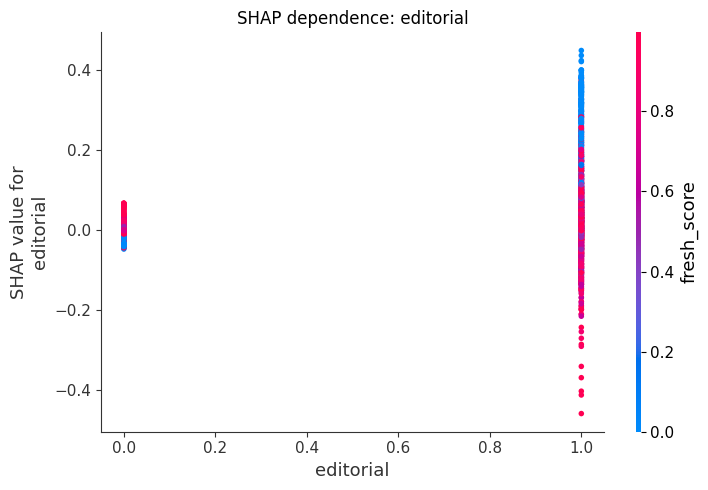

In [54]:
import shap, matplotlib.pyplot as plt
expl = shap.TreeExplainer(ranker.booster_)  # works for LGBM
# sample to keep plots fast
SAMP = X.sample(n=min(20000, len(X)), random_state=0)
sh = expl.shap_values(SAMP)
base = expl.expected_value

# 3a) Global importance (bar)
shap.summary_plot(sh, SAMP, plot_type="bar", show=False)
plt.title("Mean |SHAP| (global importance)")
plt.tight_layout(); plt.show()

# 3b) Beeswarm (distribution)
shap.summary_plot(sh, SAMP, show=False)
plt.title("SHAP beeswarm (feature effect spread)")
plt.tight_layout(); plt.show()

# 3c) Dependence: fresh_score and editorial
for feat in ["fresh_score","editorial"]:
    shap.dependence_plot(feat, sh, SAMP, show=False)
    plt.title(f"SHAP dependence: {feat}")
    plt.tight_layout(); plt.show()
